# RAMT — Exploratory Data Analysis

Publication-quality figures for the Regime-Adaptive Multimodal Transformer (RAMT) equity forecasting study.

**Run from the repository root** so paths resolve to `data/raw/` and `eda/plots/`.

## Section 1 — Setup & Data Loading

We load OHLCV and log returns for all RAMT tickers (history from **2010** onward from `data/raw/*_raw.csv`), align preprocessing (drop the initial row with undefined log return from the shift), and verify coverage. This establishes a clean panel for volatility, stationarity, and correlation analysis downstream.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as scs
import statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Plot style (fallback if style name differs by matplotlib version)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

ROOT = Path.cwd()
if not (ROOT / "data" / "raw" / "JPM_raw.csv").exists():
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
PLOTS = ROOT / "eda" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

DATA_FILES = {
    "JPM": "JPM_raw.csv",
    "RELIANCE.NS": "RELIANCE_NS_raw.csv",
    "TCS.NS": "TCS_NS_raw.csv",
    "HDFCBANK.NS": "HDFCBANK_NS_raw.csv",
}

data = {}
for ticker, fname in DATA_FILES.items():
    path = RAW / fname
    df = pd.read_csv(path, parse_dates=["Date"])
    df = df.iloc[1:].reset_index(drop=True)
    data[ticker] = df

for t, df in data.items():
    dmin, dmax = df["Date"].min(), df["Date"].max()
    print(f"{t}: shape={df.shape} | dates: {dmin.date()} → {dmax.date()}")

JPM: shape=(2765, 8) | dates: 2015-01-05 → 2025-12-31
RELIANCE.NS: shape=(2715, 8) | dates: 2015-01-02 → 2025-12-31
TCS.NS: shape=(2715, 8) | dates: 2015-01-02 → 2025-12-31
HDFCBANK.NS: shape=(2715, 8) | dates: 2015-01-02 → 2025-12-31


## Section 2 — Return Distribution Analysis

Log-return histograms with KDE and a Gaussian benchmark reveal **fat tails** (excess kurtosis vs. 3) and asymmetry—core motivation for **regime-adaptive** modeling in RAMT rather than a single Gaussian world.

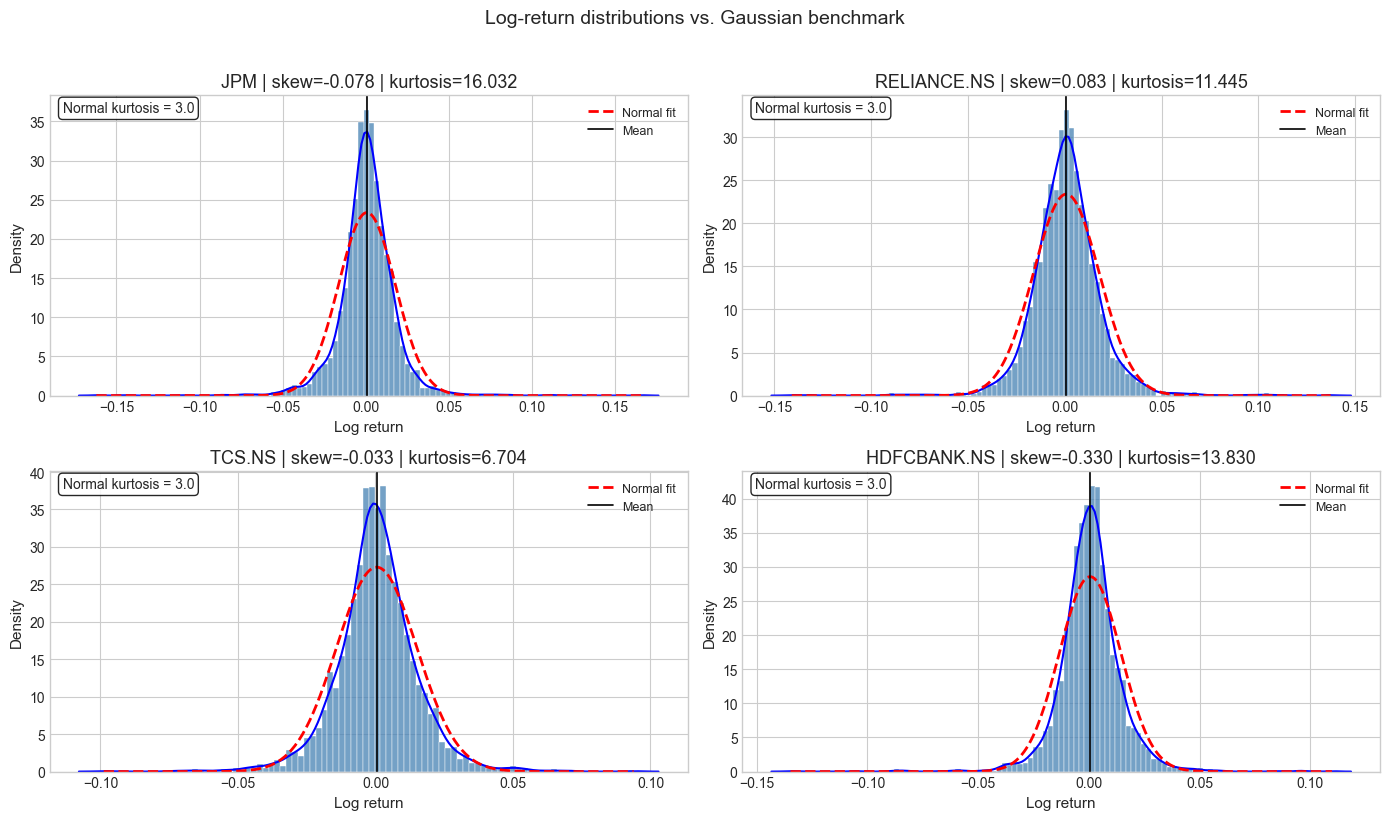

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, ticker in zip(axes, DATA_FILES.keys()):
    lr = data[ticker]["Log_Return"].dropna()
    sk = scs.skew(lr)
    kt = scs.kurtosis(lr, fisher=False)

    sns.histplot(lr, stat="density", color="steelblue", ax=ax, edgecolor="white", linewidth=0.3)
    sns.kdeplot(data=lr, color="blue", linewidth=1.5, ax=ax)

    mu, sigma = scs.norm.fit(lr)
    xs = np.linspace(lr.min(), lr.max(), 300)
    ax.plot(xs, scs.norm.pdf(xs, loc=mu, scale=sigma), color="red", linestyle="--", linewidth=2, label="Normal fit")
    ax.axvline(mu, color="black", linestyle="-", linewidth=1.2, label="Mean")

    ax.set_title(f"{ticker} | skew={sk:.3f} | kurtosis={kt:.3f}", fontsize=13)
    ax.set_xlabel("Log return", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.text(
        0.02,
        0.98,
        "Normal kurtosis = 3.0",
        transform=ax.transAxes,
        va="top",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )
    ax.legend(loc="upper right", fontsize=9)

fig.suptitle("Log-return distributions vs. Gaussian benchmark", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOTS / "return_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3 — Rolling Volatility

Twenty-day rolling volatility of log returns tracks **time-varying risk**. Overlaying known stress episodes (COVID crash, 2022 rate-hike cycle) links empirical volatility spikes to macro regimes—supporting RAMT’s focus on **regime structure**.

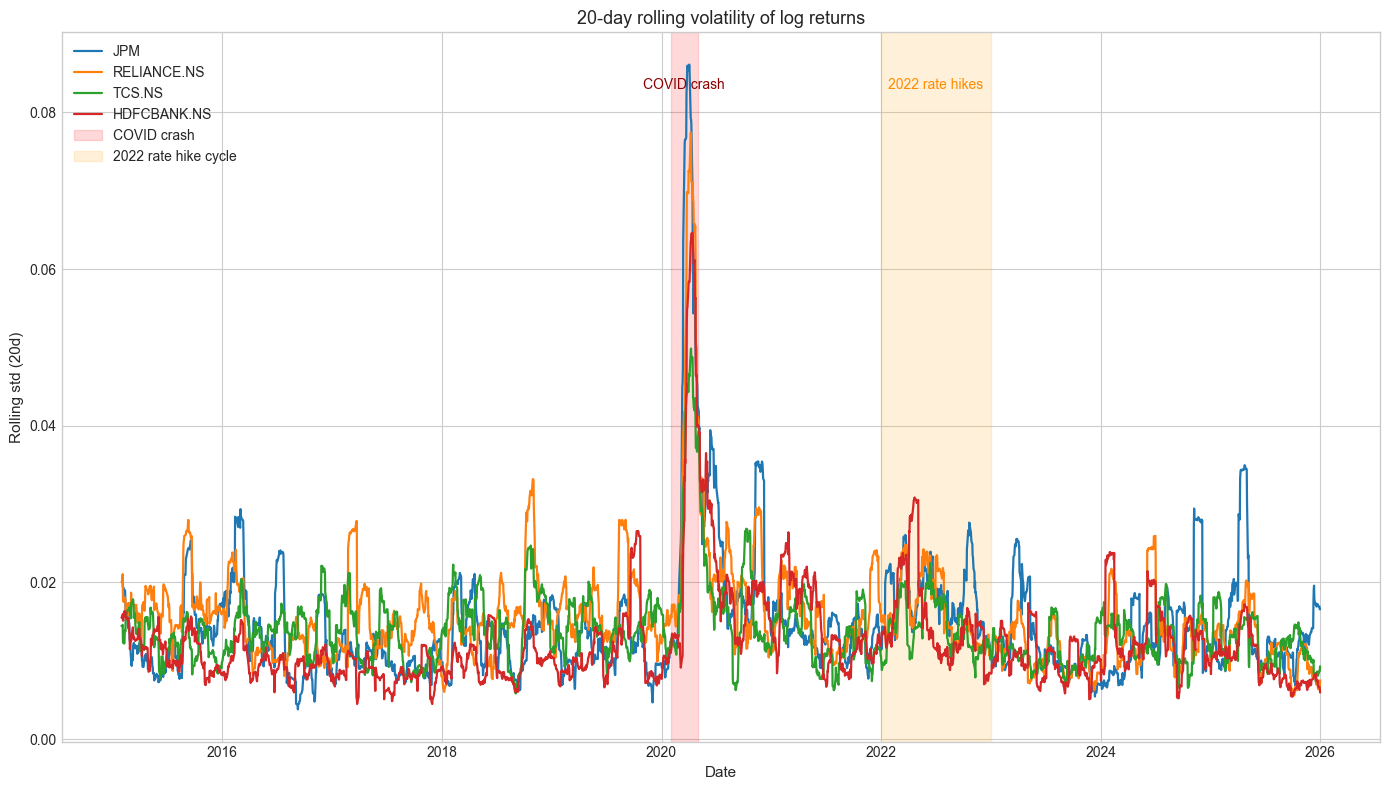

In [24]:
fig, ax = plt.subplots(figsize=(14, 8))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for (ticker, df), c in zip(data.items(), colors):
    d = df.sort_values("Date").copy()
    d["roll_vol_20"] = d["Log_Return"].rolling(20, min_periods=20).std()
    ax.plot(d["Date"], d["roll_vol_20"], label=ticker, color=c, linewidth=1.6)

ax.axvspan(
    pd.Timestamp("2020-02-01"),
    pd.Timestamp("2020-05-01"),
    color="red",
    alpha=0.15,
    label="COVID crash",
)
ax.axvspan(
    pd.Timestamp("2022-01-01"),
    pd.Timestamp("2022-12-31"),
    color="orange",
    alpha=0.15,
    label="2022 rate hike cycle",
)
ax.text(
    pd.Timestamp("2020-03-15"),
    ax.get_ylim()[1] * 0.92,
    "COVID crash",
    ha="center",
    fontsize=10,
    color="darkred",
)
ax.text(
    pd.Timestamp("2022-07-01"),
    ax.get_ylim()[1] * 0.92,
    "2022 rate hikes",
    ha="center",
    fontsize=10,
    color="darkorange",
)

ax.set_title("20-day rolling volatility of log returns", fontsize=13)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Rolling std (20d)", fontsize=11)
ax.legend(loc="upper left", fontsize=10)
fig.tight_layout()
fig.savefig(PLOTS / "rolling_volatility.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 4 — Stationarity Testing (ADF)

The Augmented Dickey–Fuller test checks whether log returns behave like a **stationary** series (no unit root). Stationary returns are the standard modeling target; **non-stationary prices** would require differencing or cointegration-aware models.

In [25]:
rows = []
for ticker, df in data.items():
    lr = df["Log_Return"].dropna()
    adf_stat, pval, *_ = adfuller(lr, autolag="AIC")
    stationary = "yes" if pval < 0.05 else "no"
    rows.append(
        {
            "Ticker": ticker,
            "ADF Statistic": adf_stat,
            "p-value": pval,
            "Stationary? (yes if p < 0.05)": stationary,
        }
    )

adf_tbl = pd.DataFrame(rows)
print(adf_tbl.to_string(index=False, float_format=lambda x: f"{x:.6g}"))

     Ticker  ADF Statistic     p-value Stationary? (yes if p < 0.05)
        JPM        -15.106 7.81761e-28                           yes
RELIANCE.NS       -15.7466  1.2377e-28                           yes
     TCS.NS       -11.9736 3.84723e-22                           yes
HDFCBANK.NS       -12.8817 4.64334e-24                           yes


**Interpretation.** If the p-value is below 0.05, we reject a unit root in log returns: the series is **stationary** in the ADF sense. That supports using log returns as the main signal for forecasting and risk modeling. Raw price levels are typically **non-stationary**; modeling them directly without transformation is usually inappropriate for standard RAMT-style sequence models, which assume stable moments over rolling windows (subject to regime change).

## Section 5 — ACF and PACF

Autocorrelation (ACF) and partial autocorrelation (PACF) of log returns reveal **linear predictability** and lag structure. RAMT can still capture non-linear dependence, but these plots benchmark whether simple AR effects are present.

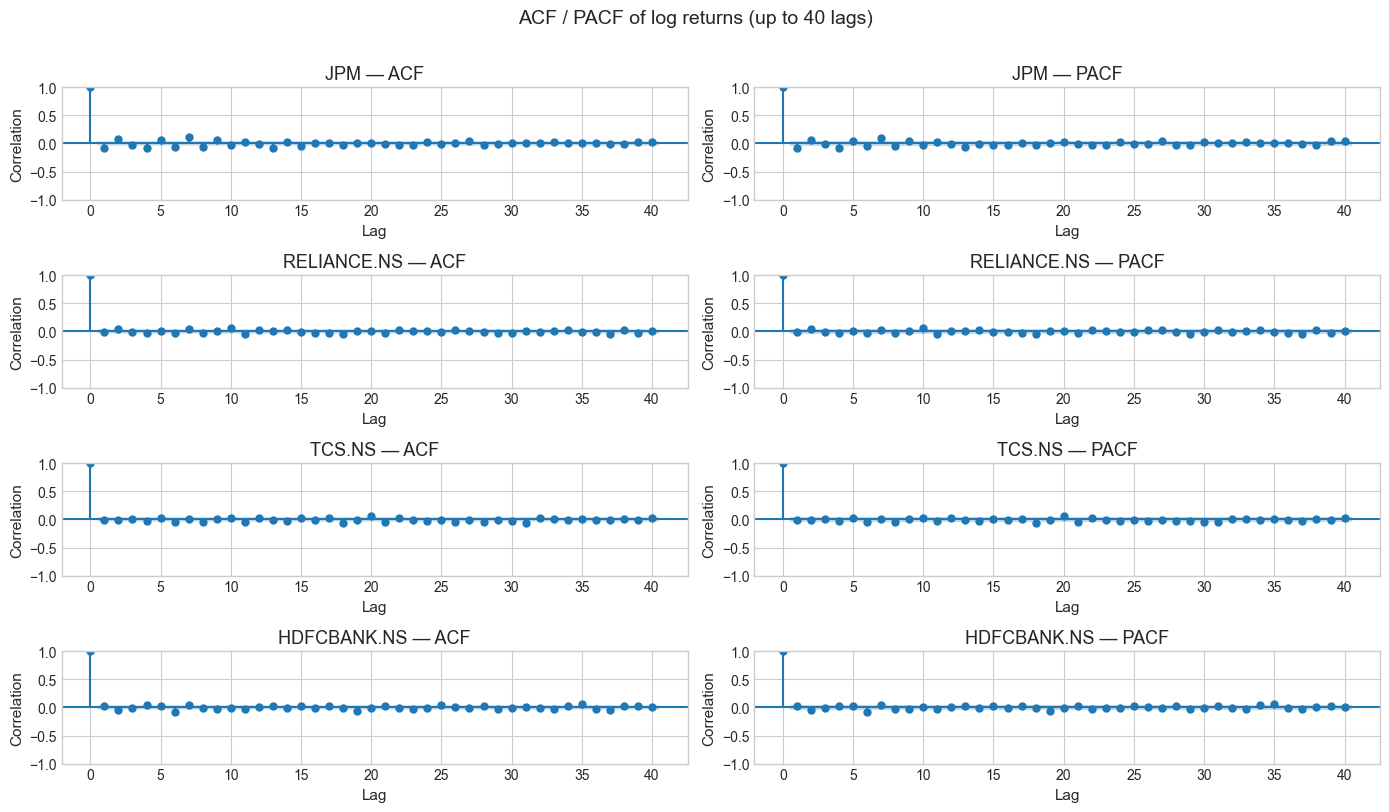

In [26]:
fig, axes = plt.subplots(4, 2, figsize=(14, 8))

for i, ticker in enumerate(DATA_FILES.keys()):
    lr = data[ticker]["Log_Return"].dropna()
    plot_acf(lr, ax=axes[i, 0], lags=40, title=f"{ticker} — ACF")
    plot_pacf(lr, ax=axes[i, 1], lags=40, title=f"{ticker} — PACF", method="ywm")

for ax in axes.flat:
    ax.set_xlabel("Lag", fontsize=11)
    ax.set_ylabel("Correlation", fontsize=11)
    ax.title.set_fontsize(13)

fig.suptitle("ACF / PACF of log returns (up to 40 lags)", fontsize=14, y=1.01)
fig.tight_layout()
fig.savefig(PLOTS / "acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6 — Rolling Cross-Asset Correlation

We compute the 60-day rolling correlation between each stock and its home market index (NIFTY50 for Indian stocks, S&P500 for JPM). Unlike a static heatmap, rolling correlation reveals how this relationship changes across market regimes — directly motivating the HMM regime detection module in RAMT.


In [ ]:
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

# Load benchmarks from disk only (no download)
nifty_df = pd.read_csv(RAW / "NIFTY50_raw.csv", parse_dates=["Date"])
sp500_df = pd.read_csv(RAW / "SP500_raw.csv", parse_dates=["Date"])

for d in (nifty_df, sp500_df):
    if "Log_Return" not in d.columns:
        d["Log_Return"] = np.log(d["Close"] / d["Close"].shift(1))
    else:
        d["Log_Return"] = d["Log_Return"].where(d["Log_Return"].notna(), np.log(d["Close"] / d["Close"].shift(1)))

nifty_df["Date"] = pd.to_datetime(nifty_df["Date"]).dt.normalize()
sp500_df["Date"] = pd.to_datetime(sp500_df["Date"]).dt.normalize()
nifty_lr = nifty_df.set_index("Date")["Log_Return"]
sp500_lr = sp500_df.set_index("Date")["Log_Return"]


def rolling_corr_60(stock_df: pd.DataFrame, index_lr: pd.Series) -> pd.Series:
    """Inner join on date; 60-day rolling Pearson correlation of log returns."""
    d = stock_df.copy()
    d["Date"] = pd.to_datetime(d["Date"]).dt.normalize()
    s = d.set_index("Date")["Log_Return"]
    m = pd.DataFrame({"stock": s, "idx": index_lr}).dropna()
    return m["stock"].rolling(60, min_periods=60).corr(m["idx"])


indian_specs = [
    ("RELIANCE.NS", "#1f77b4", "RELIANCE"),
    ("TCS.NS", "#ff7f0e", "TCS"),
    ("HDFCBANK.NS", "#2ca02c", "HDFCBANK"),
]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ticker, color, lab in indian_specs:
    rc = rolling_corr_60(data[ticker], nifty_lr)
    ax_top.plot(rc.index, rc.values, color=color, linewidth=1.5, label=lab)

rc_jpm = rolling_corr_60(data["JPM"], sp500_lr)
ax_bot.plot(rc_jpm.index, rc_jpm.values, color="#d62728", linewidth=1.6, label="JPM")

crisis_covid = (pd.Timestamp("2020-02-01"), pd.Timestamp("2020-05-01"))
crisis_2022 = (pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-31"))

for ax in (ax_top, ax_bot):
    ax.axhline(0.0, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax.axvspan(crisis_covid[0], crisis_covid[1], color="red", alpha=0.2, label="COVID crash")
    ax.axvspan(crisis_2022[0], crisis_2022[1], color="orange", alpha=0.2, label="Rate hike cycle")
    ax.set_ylabel("Rolling Correlation", fontsize=11)
    ax.legend(loc="lower left", fontsize=9)

ax_top.set_title("Indian Equities vs NIFTY50 — 60-day Rolling Correlation", fontsize=13)
ax_bot.set_title("JPM vs S&P500 — 60-day Rolling Correlation", fontsize=13)
ax_bot.set_xlabel("Date", fontsize=11)

fig.tight_layout()
fig.savefig(PLOTS / "rolling_correlation.png", dpi=150, bbox_inches="tight")

heatmap_path = PLOTS / "correlation_heatmap.png"
if heatmap_path.is_file():
    heatmap_path.unlink()

plt.show()


### Interpretation

During stable market periods, Indian equities maintain high correlation with NIFTY50. During the COVID crash (Feb–May 2020), correlations spike sharply, reflecting synchronized panic selling across all stocks. The 2022 rate hike cycle shows a different pattern — gradual decorrelation as sector-specific factors dominate. This non-stationary behavior of correlations confirms that a static feature would be insufficient; the HMM regime module captures exactly these structural shifts.


## Section 7 — Summary Stats Table

A compact table of return moments, extremes, and ADF **p-values** supports the written report: fat tails, skew, and stationarity evidence in one view.

In [28]:
summary_rows = []
for ticker, df in data.items():
    lr = df["Log_Return"].dropna()
    _, pval, *_ = adfuller(lr, autolag="AIC")
    summary_rows.append(
        {
            "Ticker": ticker,
            "Mean Return": lr.mean(),
            "Std": lr.std(),
            "Skewness": scs.skew(lr),
            "Kurtosis": scs.kurtosis(lr, fisher=False),
            "Min (worst day)": lr.min(),
            "Max (best day)": lr.max(),
            "ADF p-value": pval,
        }
    )

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(PLOTS / "summary_stats.csv", index=False)

     Ticker  Mean Return      Std  Skewness  Kurtosis  Min (worst day)  Max (best day)  ADF p-value
        JPM     0.000698 0.017079 -0.077929 16.032445        -0.162106        0.165620 7.817609e-28
RELIANCE.NS     0.000778 0.017053  0.082601 11.444774        -0.141032        0.137307 1.237696e-28
     TCS.NS     0.000427 0.014617 -0.032966  6.704440        -0.098830        0.093901 3.847225e-22
HDFCBANK.NS     0.000559 0.013963 -0.329715 13.830293        -0.134754        0.109747 4.643343e-24
